In [10]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator
from src.dataloading import ShallowDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeLSTMModel, SimpleGCNModel, GATv2LSTMModel

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )
baselinedata            = BaseLineDataLoaderManager(data_orchestrator)
shallowdata             = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
deepdata                = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdata_1             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdata_2             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdata_3             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_4').construct_dataloaders()
graphdata_4             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()
graphdata_5             = GraphDataLoaderManager(data_orchestrator).retrieve_dynamic_graph('dynamic_commuter2', timesteps = range(2006,2021)).construct_dataloaders()

loading graphs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 339.45it/s]


In [11]:
from src.models.base import BaseModel
def plot_timeseries_model(model: BaseModel, node: int = 26):

    raw_figure = model.show_forecasts(node)

    figure = (raw_figure
        .labels.change_suptitle(f'{model.name}','bold',12)
        .labels.change_title('Predictions node 26: Hannover')
        .labels.change_xlab('time')
        .labels.change_ylab('incidence')
        .legend.set_labels(['true incidence','predicted incidence'])
        .change_figsize(10,5).legend.move('upper left')) 

    return figure   

## Baseline models

### Persistence

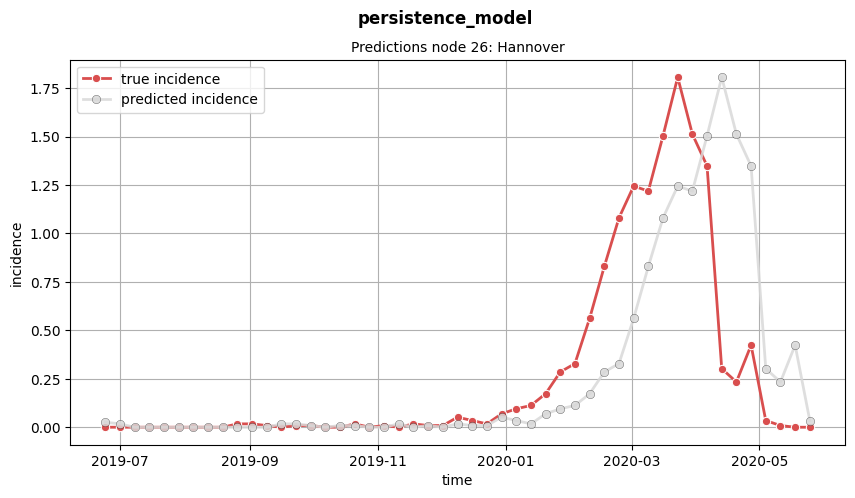

In [12]:
persistence = PersistenceModel(baselinedata, name = 'persistence_model')
persistence.forecast('test')
plot_timeseries_model(persistence).show()

### Climateology

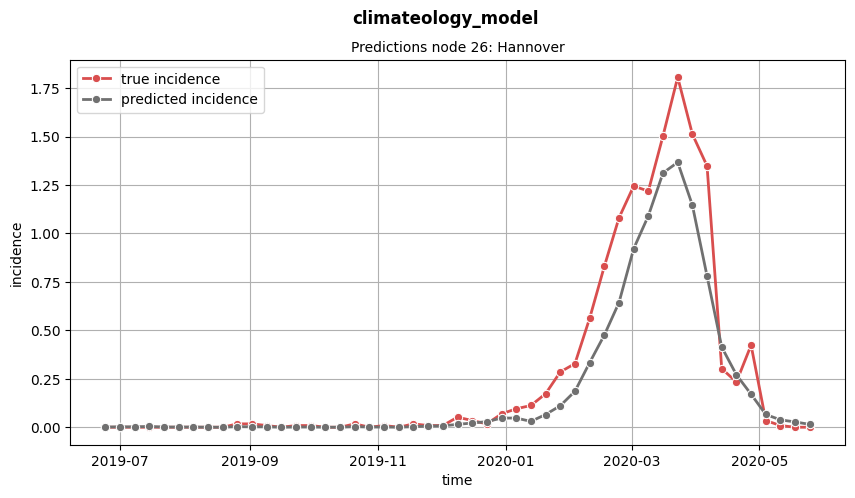

In [13]:
climateology = ClimateologyModel(baselinedata, name = 'climateology_model')
climateology.forecast('test')
plot_timeseries_model(climateology).show()

## Deep Models

In [14]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

### LSTM

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3456


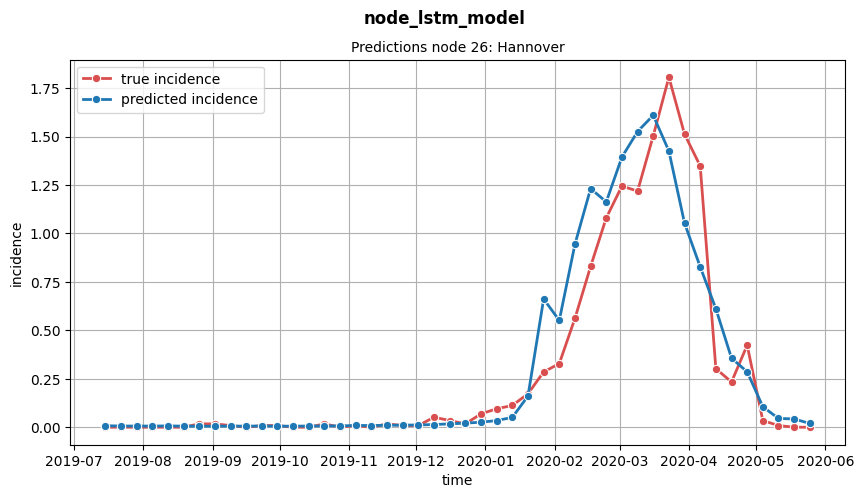

In [15]:
lstm = NodeLSTMModel(deepdata, name = 'Node_LSTM_Model')
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
plot_timeseries_model(lstm).show()

### GCNs

In [16]:
graphdata_1             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdata_2             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdata_3             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_4').construct_dataloaders()
graphdata_4             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()
graphdata_5             = GraphDataLoaderManager(data_orchestrator).retrieve_dynamic_graph('dynamic_commuter2', timesteps = range(2006,2021)).construct_dataloaders()

loading graphs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 262.79it/s]


#### GCN1

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4116


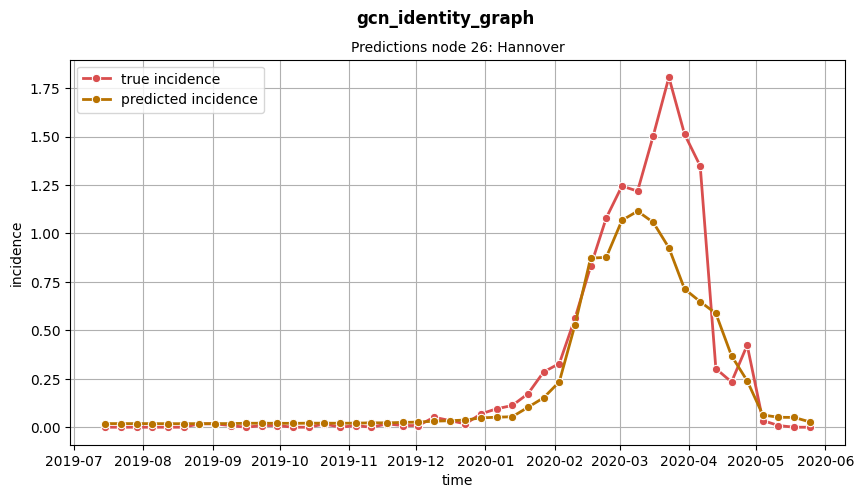

In [17]:
gcn1 = SimpleGCNModel(graphdata_1, name = 'gcn_identity_graph')
gcn1.set_model_hparams()
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
plot_timeseries_model(gcn1).show()

#### GCN2

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4015


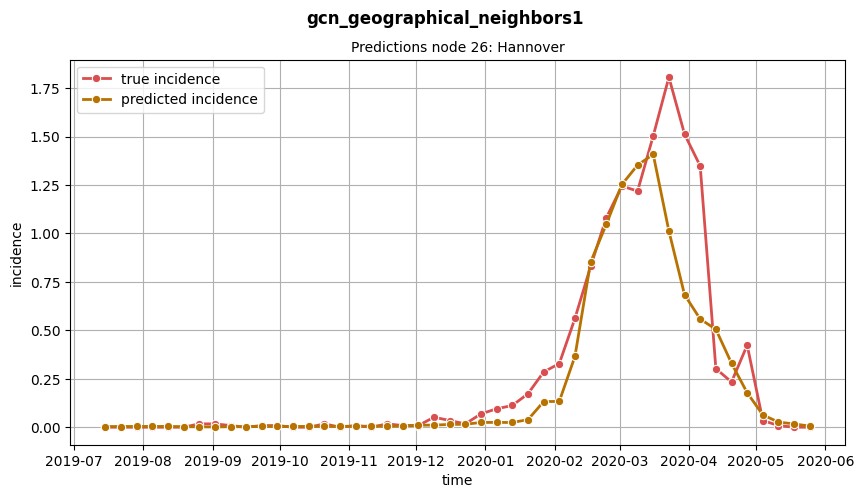

In [18]:
gcn2 = SimpleGCNModel(graphdata_2, name = 'gcn_geographical_neighbors1')
gcn2.set_model_hparams()
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
plot_timeseries_model(gcn2).show()


#### GCN3

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 2.1669


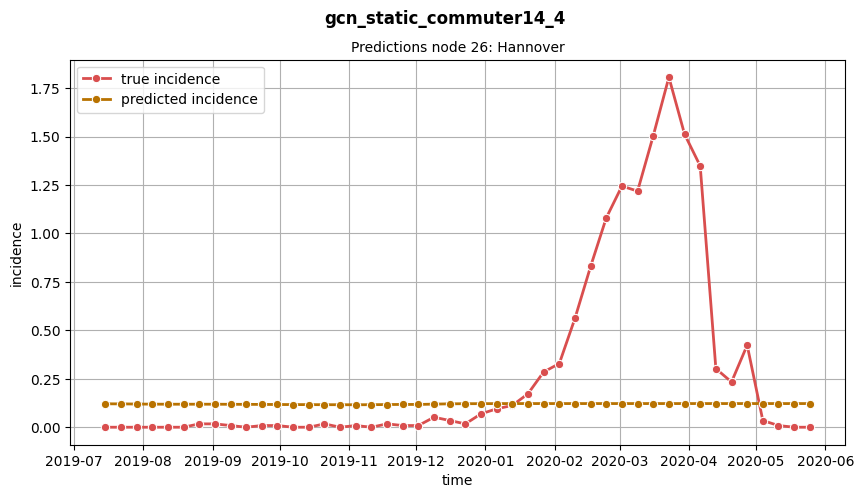

In [19]:
gcn3 = SimpleGCNModel(graphdata_3, name = 'gcn_static_commuter14_4')
gcn3.set_model_hparams()
gcn3.set_global_hparams(**global_hparams)
gcn3.train()
gcn3.forecast('test')
plot_timeseries_model(gcn3).show()

#### GCN4

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4265


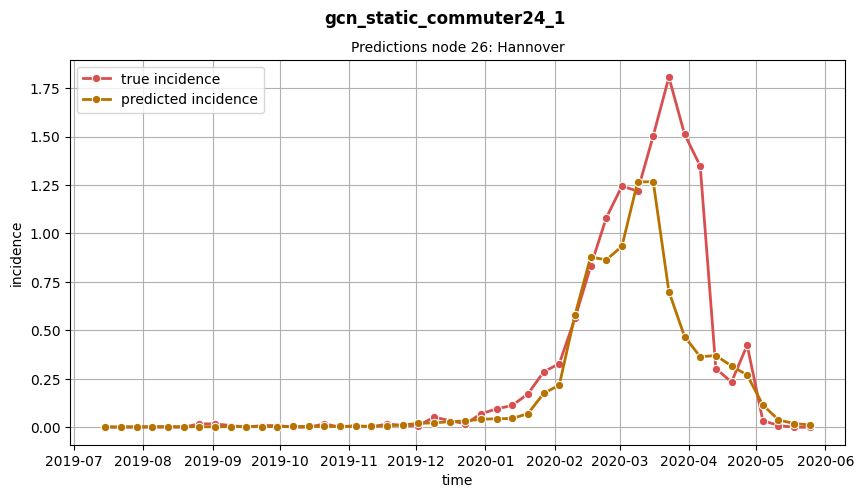

In [20]:
gcn4 = SimpleGCNModel(graphdata_4, name = 'gcn_static_commuter24_1')
gcn4.set_model_hparams()
gcn4.set_global_hparams(**global_hparams)
gcn4.train()
gcn4.forecast('test')
plot_timeseries_model(gcn4).show()

#### GCN5

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5770


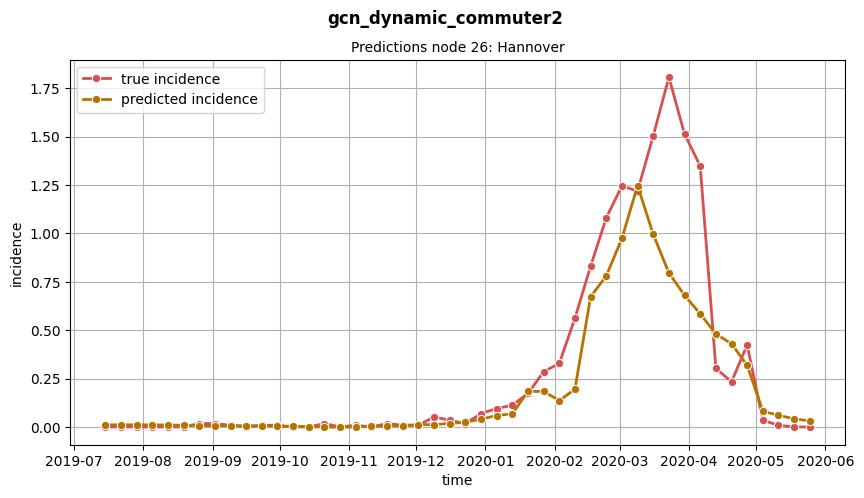

In [21]:
gcn5 = SimpleGCNModel(graphdata_5, name = 'gcn_dynamic_commuter2')
gcn5.set_model_hparams()
gcn5.set_global_hparams(**global_hparams)
gcn5.train()
gcn5.forecast('test')
plot_timeseries_model(gcn5).show()

### GATv2

#### GATV2.1

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3595


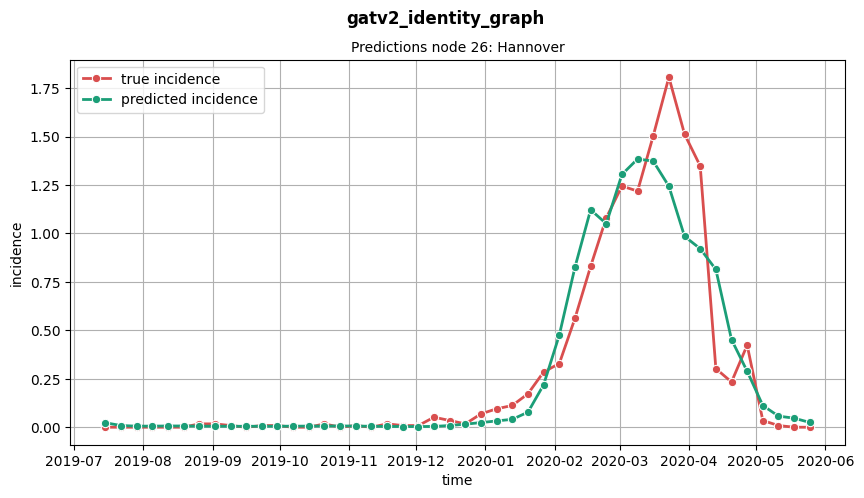

In [22]:
gatv2_1 = GATv2LSTMModel(graphdata_1, name = 'gatv2_identity_graph')
gatv2_1.set_model_hparams()
gatv2_1.set_global_hparams(**global_hparams)
gatv2_1.train()
gatv2_1.forecast('test')
plot_timeseries_model(gatv2_1).show()

#### GATV2.2

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3642


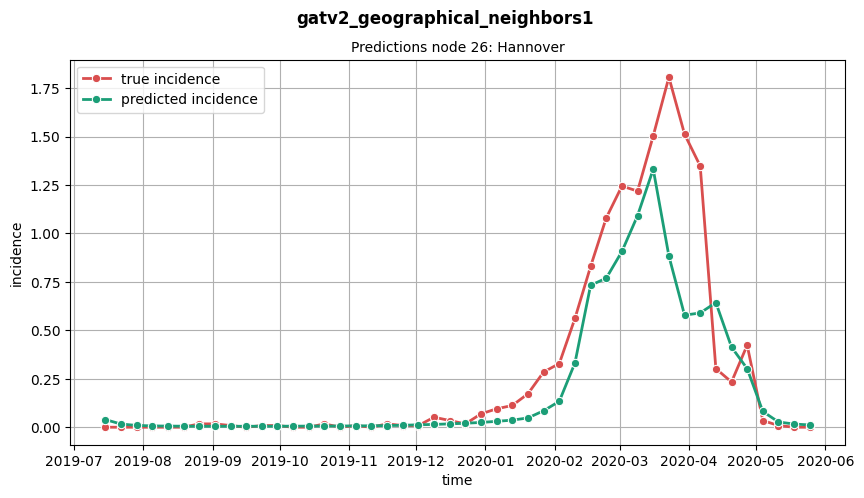

In [23]:
gatv2_2 = GATv2LSTMModel(graphdata_2, name = 'gatv2_geographical_neighbors1')
gatv2_2.set_model_hparams()
gatv2_2.set_global_hparams(**global_hparams)
gatv2_2.train()
gatv2_2.forecast('test')
plot_timeseries_model(gatv2_2).show()

#### GATv2.3

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3517


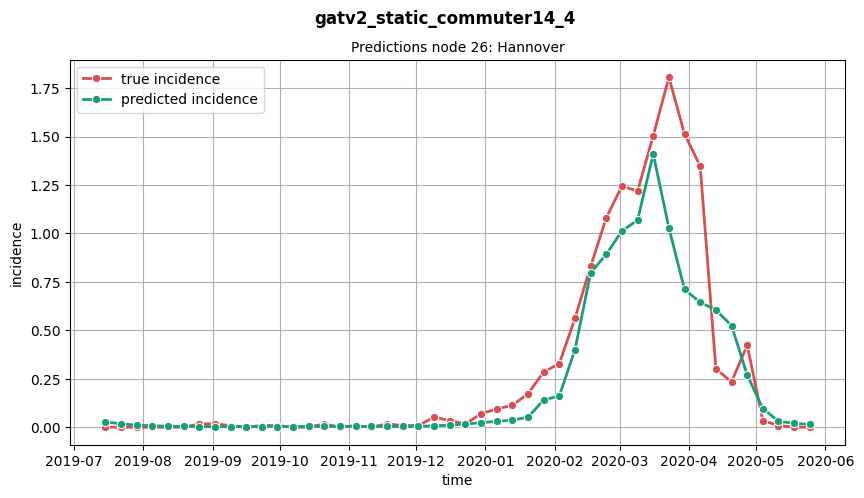

In [24]:
gatv2_3 = GATv2LSTMModel(graphdata_3, name = 'gatv2_static_commuter14_4')
gatv2_3.set_model_hparams()
gatv2_3.set_global_hparams(**global_hparams)
gatv2_3.train()
gatv2_3.forecast('test')
plot_timeseries_model(gatv2_3).show()

#### GATv2.4

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3650


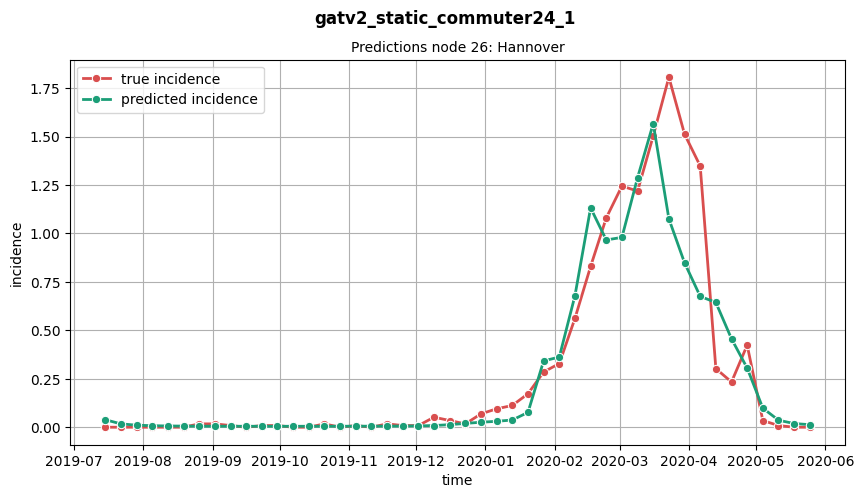

In [25]:
gatv2_4 = GATv2LSTMModel(graphdata_4, name = 'gatv2_static_commuter24_1')
gatv2_4.set_model_hparams()
gatv2_4.set_global_hparams(**global_hparams)
gatv2_4.train()
gatv2_4.forecast('test')
plot_timeseries_model(gatv2_4).show()

#### GATv2.5

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3654


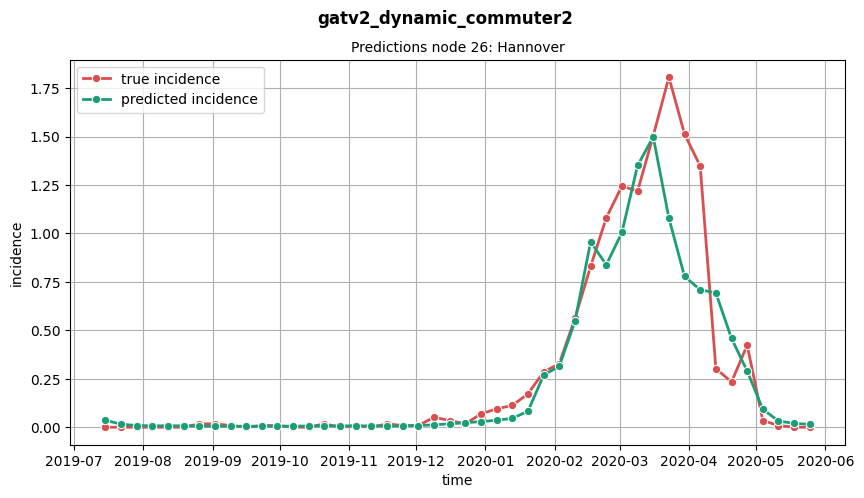

In [26]:
gatv2_5 = GATv2LSTMModel(graphdata_5, name = 'gatv2_dynamic_commuter2')
gatv2_5.set_model_hparams()
gatv2_5.set_global_hparams(**global_hparams)
gatv2_5.train()
gatv2_5.forecast('test')
plot_timeseries_model(gatv2_5).show()

In [27]:
from src.evaluation import Evaluator

evaluation_experiment_gcn   = Evaluator([persistence, climateology, lstm, gcn1, gcn2, gcn3, gcn4, gcn5]).add_evaluation()
f_merged_raw_gcn            = evaluation_experiment_gcn.plotter.plot_metric_compilation(subfig_size = (8,4), metrics = ['rmse','pearson_corr','spearman_corr','ccc'], plot_types = ['box','box','box','box']);

evaluation_experiment_stgnn   = Evaluator([persistence, climateology, lstm, gatv2_1, gatv2_2, gatv2_3, gatv2_4, gatv2_5]).add_evaluation()
f_merged_raw_stgnn            = evaluation_experiment_stgnn.plotter.plot_metric_compilation(subfig_size = (8,4), metrics = ['rmse','pearson_corr','spearman_corr','ccc'], plot_types = ['box','box','box','box']);




computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:07<00:00,  1.31s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

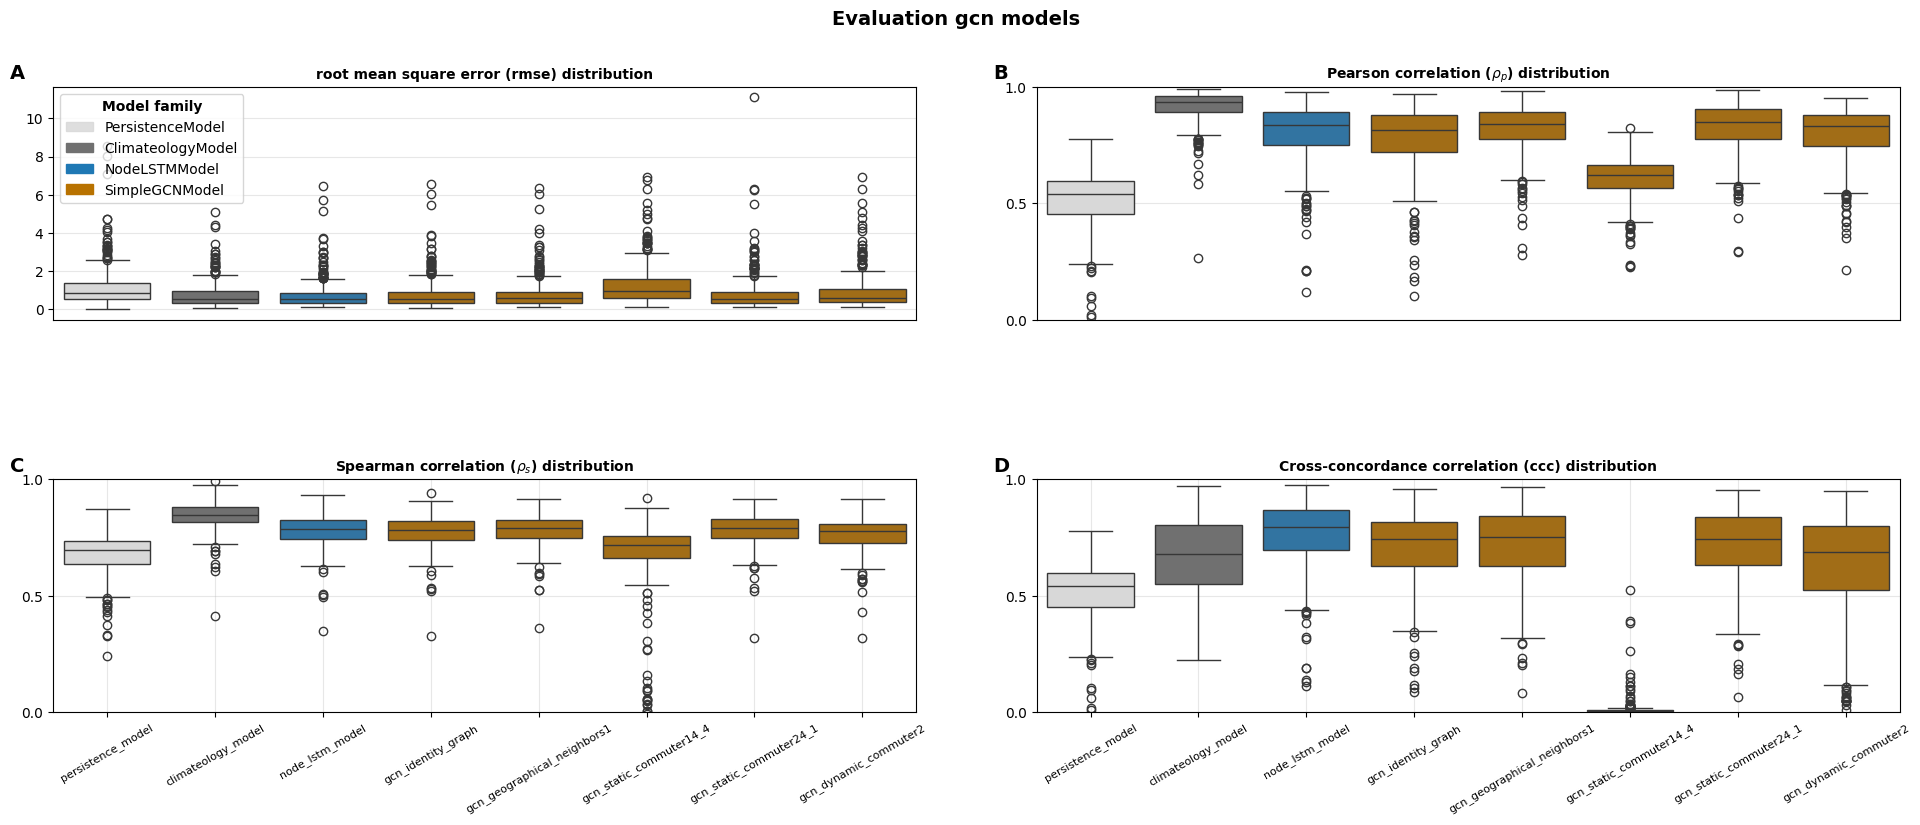

In [28]:
f_evaluation_gcn = (f_merged_raw_gcn
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 0)      
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 1)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 2)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 1)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 2)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 3)    
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)
    .layout.set_ylim([0,1],ax = 3)      
    .ticks.rotate_xticks(30)      
    .labels.change_legend_title('Model family',fontweight = 'bold',ax=0)
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)       
    )
f_evaluation_gcn.show()

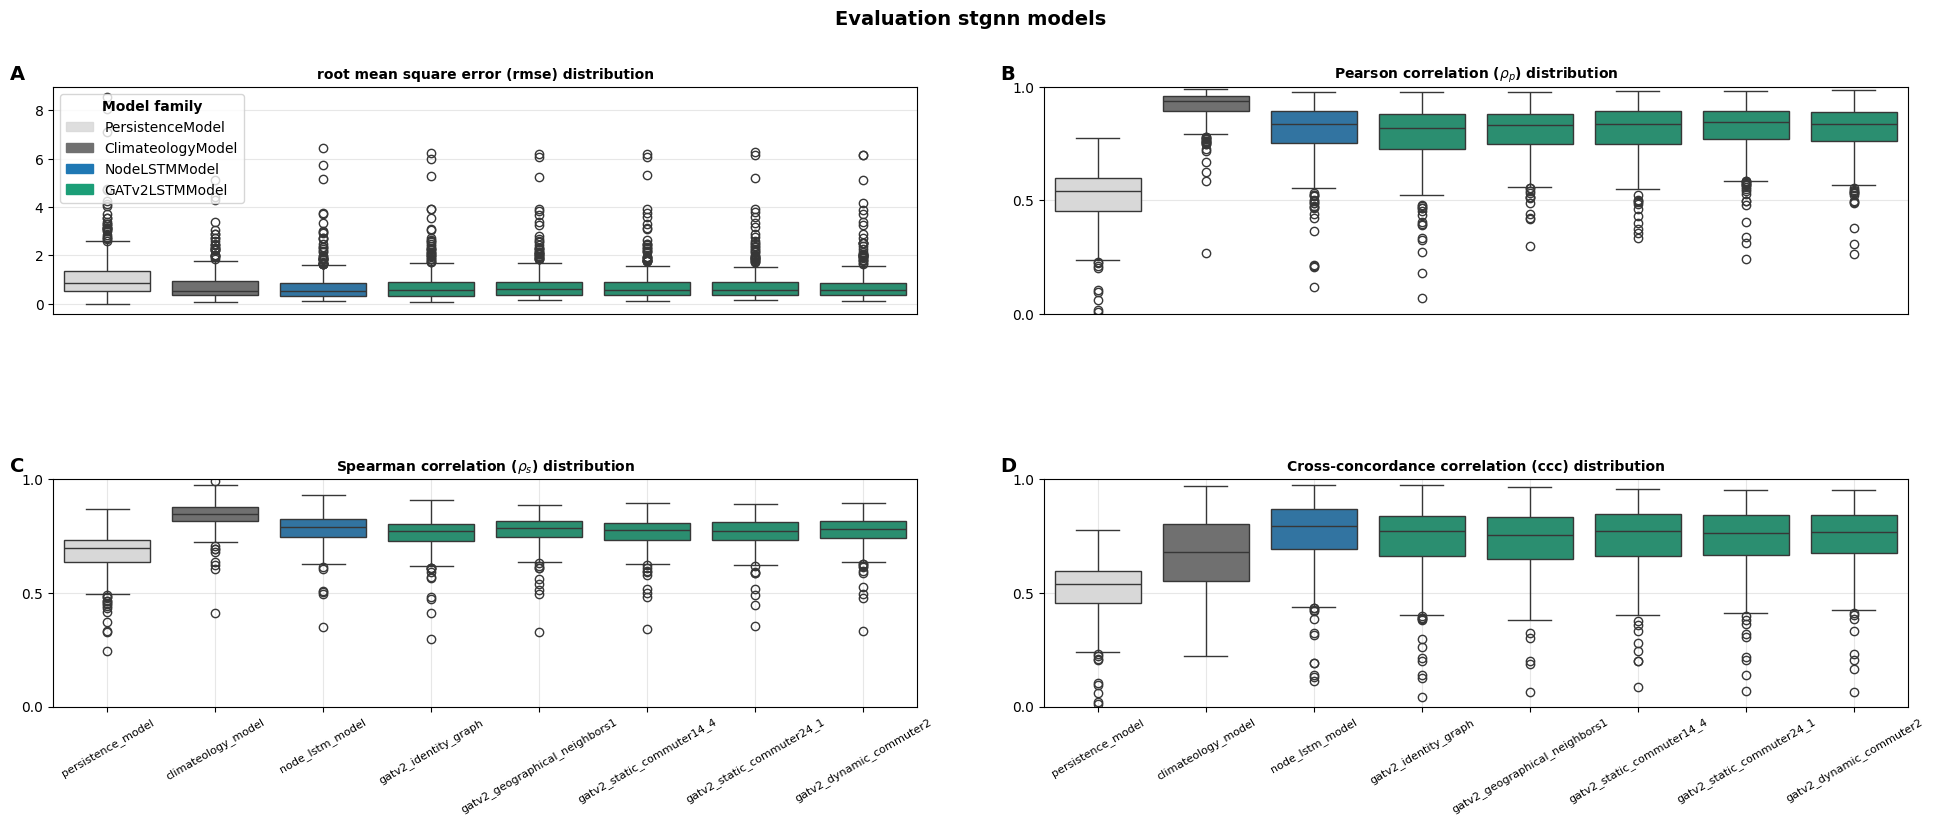

In [29]:
f_evaluation_stgnn = (f_merged_raw_stgnn
    .labels.change_suptitle(suptitle='Evaluation stgnn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 0)      
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 1)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 2)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 1)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 2)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 3)    
    .ticks.rotate_xticks(30)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)
    .layout.set_ylim([0,1],ax = 3)        
    .labels.change_legend_title('Model family',fontweight = 'bold',ax=0)
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)         
    )
f_evaluation_stgnn.show()

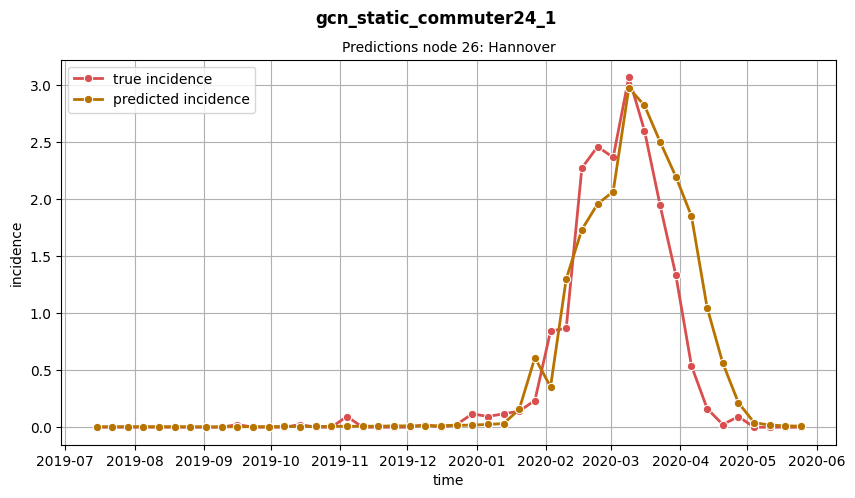

In [30]:
plot_timeseries_model(gcn4, 183).show()

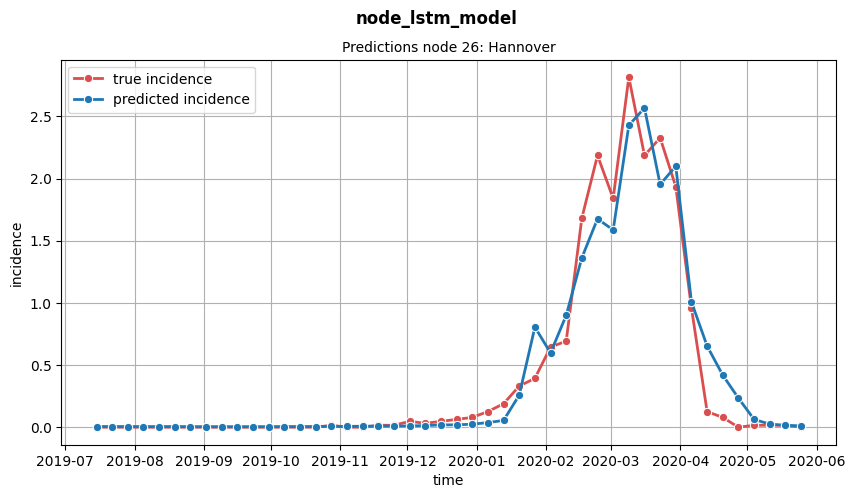

In [31]:
plot_timeseries_model(lstm, 178).show()

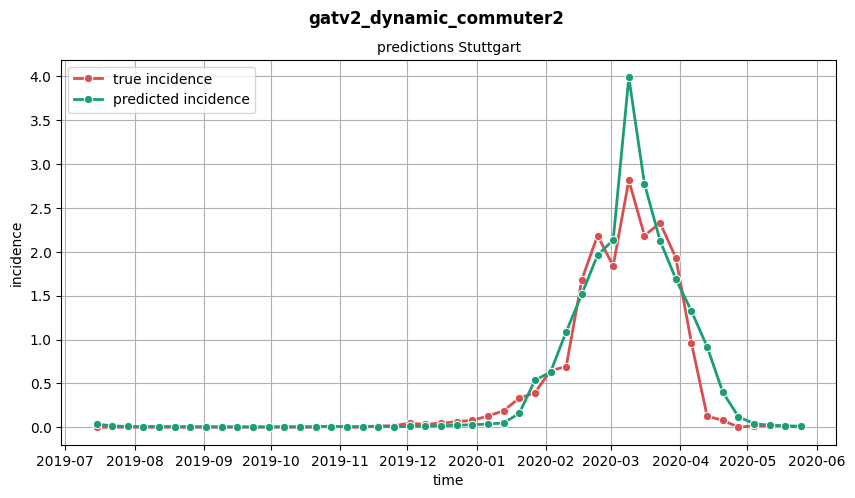

In [32]:
plot_timeseries_model(gatv2_5, 178).labels.change_title('predictions Stuttgart').show()

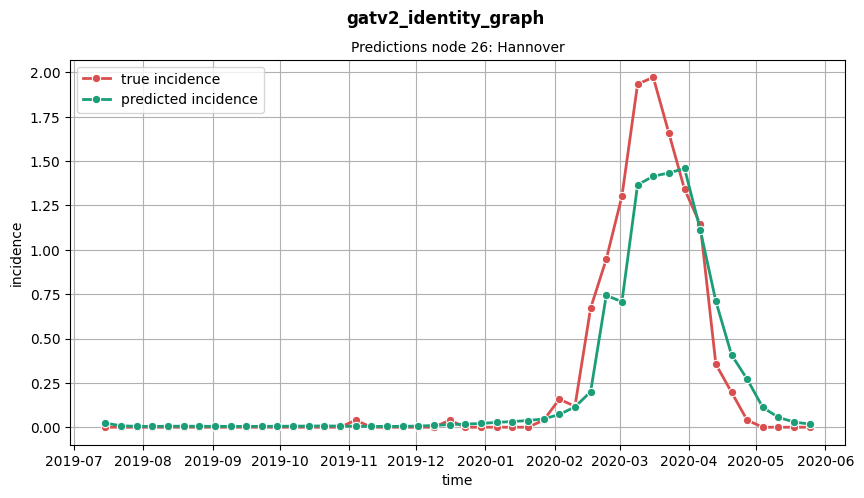

In [33]:
plot_timeseries_model(gatv2_1, 309).show()

In [34]:
from typing import Optional

def get_nuts_node(data_orchestrator: DataOrchestrator, nuts3_key: Optional[str] = None, nuts3_name: Optional[str] = None, node: Optional[int] = None):
    harmdf = data_orchestrator.data_context.nuts_names
    if nuts3_key:
        return harmdf[harmdf['nuts3_key'] == nuts3_key].reset_index()
    elif nuts3_name:
        return harmdf[harmdf['nuts3_name'] == nuts3_name].reset_index()
    elif node:
        return harmdf[harmdf['node'] == node].reset_index()            
    else:
        raise ValueError('Please supply either a nuts3_key, nuts3_name or a node idx')

    

In [35]:
get_nuts_node(data_orchestrator,nuts3_key='08111')

,index,nuts3_key,nuts3_name,node
0,178,08111,Stuttgart,178


In [36]:
from src.models.base import BaseModel
def plot_timeseries_multiple_model(model: BaseModel, node: int = 26):

    raw_figure = model.show_forecasts(node)

    figure = (raw_figure
        .labels.change_suptitle(f'{model.name}','bold',12)
        .labels.change_title('Predictions node 26: Hannover')
        .labels.change_xlab('time')
        .labels.change_ylab('incidence')
        .legend.set_labels(['true incidence','predicted incidence'])
        .change_figsize(10,5).legend.move('upper left')) 

    return figure   

In [37]:
from src.evaluation import Evaluator

evaluation      = Evaluator([climateology, lstm, gcn4, gatv2_5]).add_evaluation()


timeseries_compilation_raw = evaluation.plotter.plot_timeseries([15,26,309,178], 0)

timeseries_compilation = (timeseries_compilation_raw
        .labels.change_suptitle('Predicted timeseries by baseline models in 4 districts', fontweight = 'bold', fontsize = 14)         
        .labels.set_suptitle_y(y=1.05)
        .labels.change_title(title = 'Hamburg',  ax = 0, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Hannover', ax = 1, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Stuttgart',   ax = 2, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Augsburg',  ax = 3, fontsize = 12, fontweight = 'bold')   
        .labels.change_ylab('incidence per 10 000', ax = 0)
        .labels.change_ylab('incidence per 10 000', ax = 2)
        .labels.set_tag('A', y = 1.04, ax = 0)
        .labels.set_tag('B', y = 1.04, ax = 1)
        .labels.set_tag('C', y = 1.04, ax = 2)
        .labels.set_tag('D', y = 1.04, ax = 3)                        
        .change_figsize(14,12) 
        .layout.grid('off')
        )




computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.54it/s]


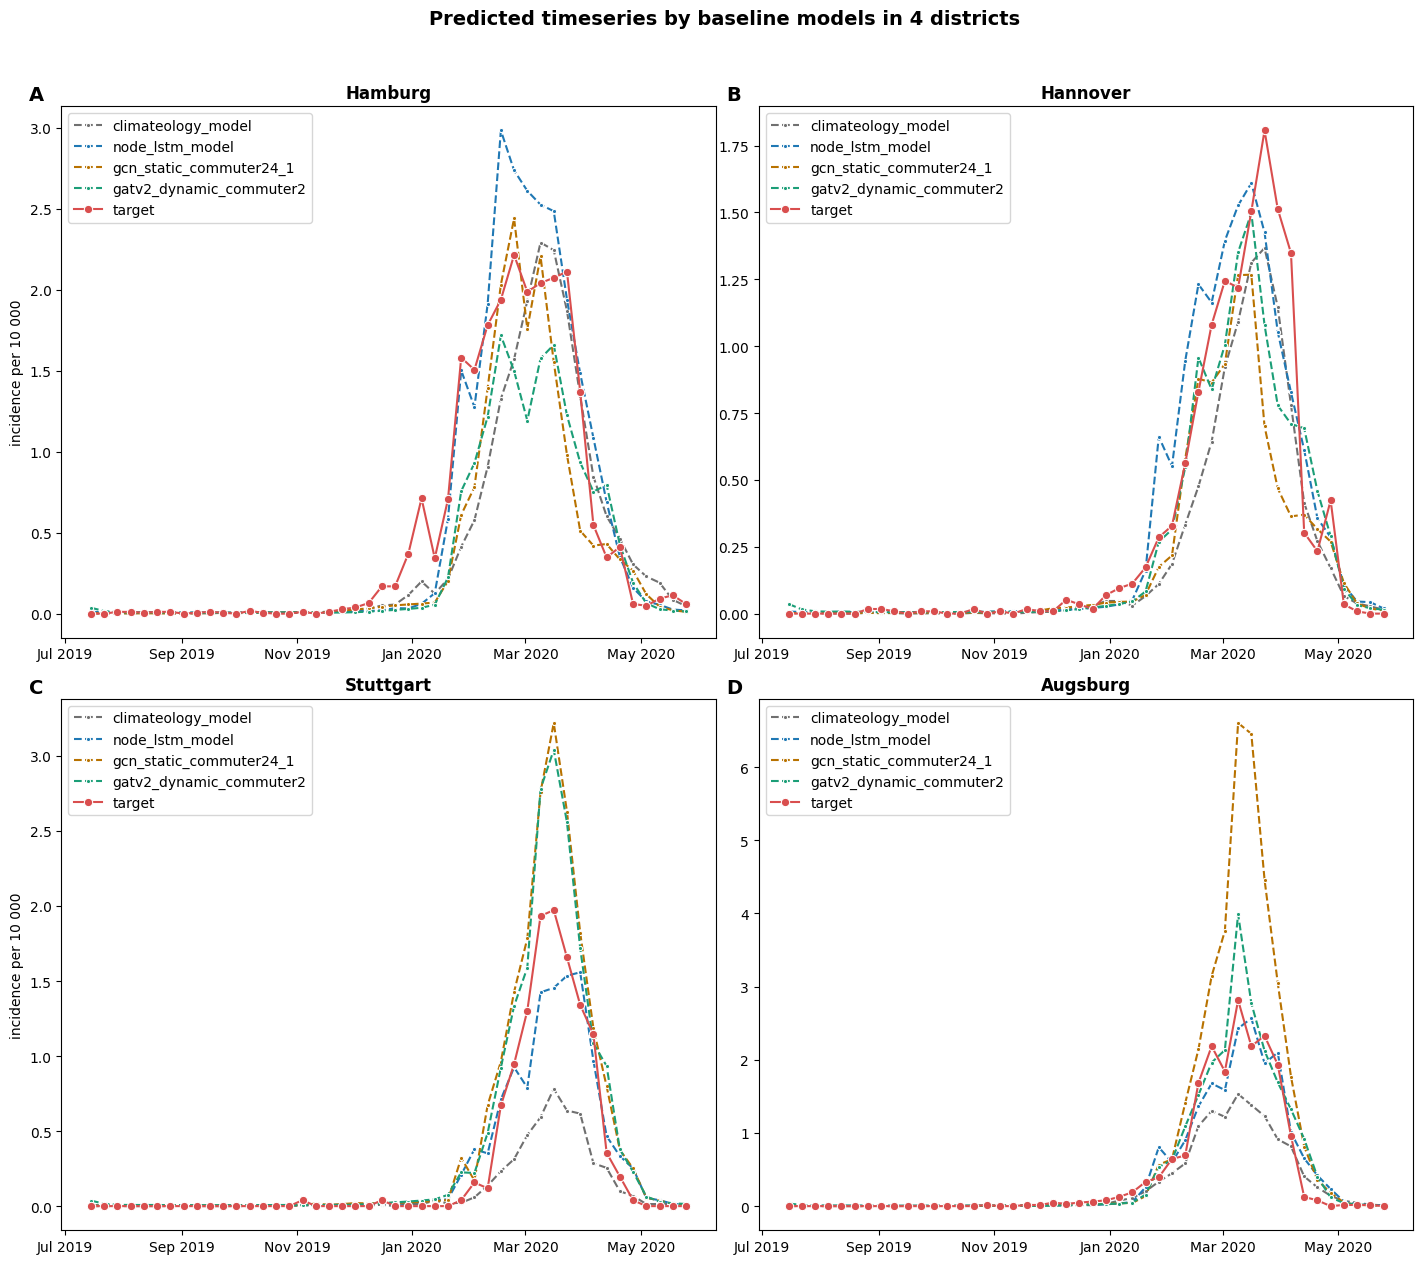

In [38]:
timeseries_compilation.show()

In [39]:
from src.plotting import ManagedFigure, convert_managedfigure, calculate_subplot_layout
from typing import Union, List, Literal
from src.utils import testcolor
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.patheffects as pe
@convert_managedfigure
def show_forecasts(models: List[BaseModel], node_idx:    int           = 178) -> ManagedFigure:
    

    horizon = 0


    n_plots     = len(models)
    # nrows, ncols, figsize = calculate_subplot_layout(n_plots, 10, 5)
    fig, axes   = plt.subplots(3 ,2, figsize = (20,16))
        
    if n_plots > 1:
        axes        = axes.flatten()           
    else:
        axes = [axes]

    for counter, ml in enumerate(models):
        ax = axes[counter]
        predictioncollection = ml.predictions.get_preds('test')
        evaluation_df        = predictioncollection.get_original(0)
        weeks_ahead          = int(ml.dataloadermanager.dataorchestrator.config.horizon_leadtime + horizon)
        nutscode = ml.tokenization_map['idx_id'][node_idx]
        nodename = ml.nutsnames[ml.nutsnames[f'{ml.nutslevel}_key'] == nutscode][f'{ml.nutslevel}_name'].iloc[0]

        evaluation_df_node  = evaluation_df[evaluation_df['node'] == node_idx]

        sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target',    color = testcolor,          marker = 'o',   label = 'ground truth', ax = ax, linewidth = 2)  
        if ml.name == 'persistence_model':
            markercolor = 'black'
        else:
            markercolor = 'white'
        sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = ml.model_color,   marker = 'o',   label = f'predictions {ml.name}',    ax = ax, linewidth = 2,    markeredgecolor=markercolor,markeredgewidth=0.2)


        ax.set_title(ml.name.replace("_", " "), fontsize = 10, fontweight = 'bold')
        ax.set_xlabel("")            
        ax.grid()   

    title = f'Predictions {nodename}, {weeks_ahead} weeks ahead' 
     
    
    plt.suptitle(title, fontsize = 12, fontweight = 'bold')
    plt.close()
    return fig


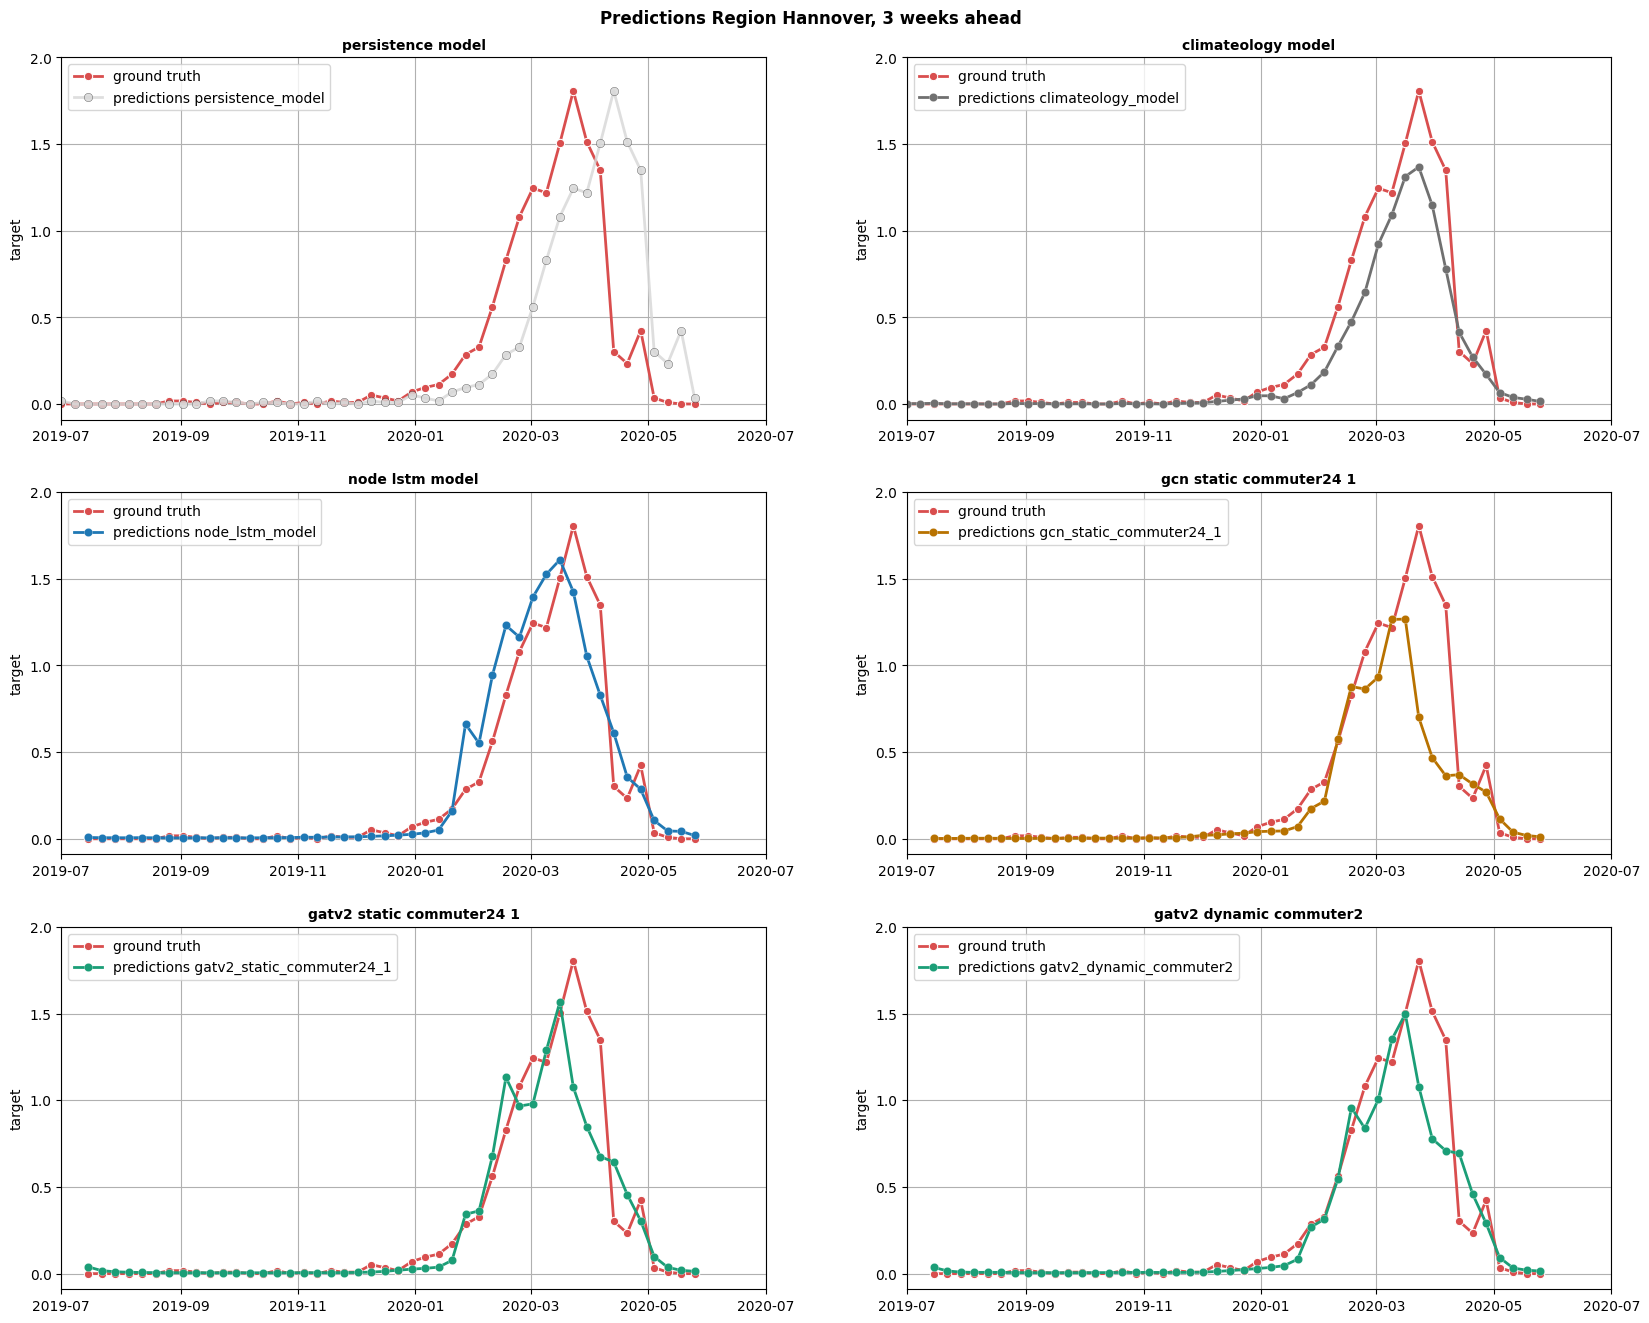

In [40]:
import pandas as pd

show_forecasts([persistence, climateology, lstm, gcn4, gatv2_4, gatv2_5], 26).layout.set_xlim([pd.to_datetime('2019-07-01'),pd.to_datetime('2020-07-01')]).ticks.change_yticks([0,0.5,1,1.5,2]).labels.set_suptitle_y(y=0.91).show()